# MNIST as contextual bandits

# Run experiment and store results

In [ ]:
%%time
!bash run_mnist_refactor.sh

Running FLoRES agent
Results saved to output/FLoRES_eps_5_20250902.pkl
Average cumulative reward: 30471.80
Total time: 457.9995 seconds

Running LoFi agent
Results saved to output/LoFi_eps_5_20250902.pkl
Average cumulative reward: 24628.10
Total time: 220.7402 seconds

Running FLoRESLite agent


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import seaborn as sns

In [67]:
pd.set_option("display.float_format", lambda x: format(x, "0,.2f"))

In [63]:
sns.set_palette("colorblind")
%config InlineBackend.figure_format = "retina"

In [5]:
agents = ["LRKF", "FLoRES", "FLoRESLite", "adamw", "LoFi", "muon"]

In [328]:
def plot_rewards(rewards, hatch, color, **kwargs):
    rewards = pd.DataFrame(rewards)

    stat = rewards.expanding(min_periods=1000).mean()
    median = stat.mean(axis=1)
    # lbound = stat.quantile(0.25, axis=1)
    # ubound = stat.quantile(0.75, axis=1)
    
    median.plot(color=color, **kwargs)
    # plt.fill_between(median.index, lbound, ubound, alpha=0.2, color=color, hatch=hatch)

In [484]:
def plot_regret(rewards, hatch, color, **kwargs):
    rewards = pd.DataFrame(rewards)
    rewards_oracle = np.ones(len(rewards))[:, None]
    regret = rewards_oracle - rewards

    regret = regret.cumsum()
    median = regret.mean(axis=1)
    # lbound = stat.quantile(0.25, axis=1)
    # ubound = stat.quantile(0.75, axis=1)
    
    median.plot(color=color, **kwargs)
    # plt.fill_between(median.index, lbound, ubound, alpha=0.2, color=color, hatch=hatch)

In [504]:
date = "20250902"

In [505]:
agents = ["LRKF", "FLoRES", "FLoRESLite", "adamw", "LoFi", "muon"]

In [506]:
agent_map = {agent: agent for agent in agents}
agent_map["FLoRES"] = "HiLoFi"
agent_map["FLoRESLite"] = "LoLoFi"

CPU times: user 895 ms, sys: 1.69 ms, total: 897 ms
Wall time: 895 ms


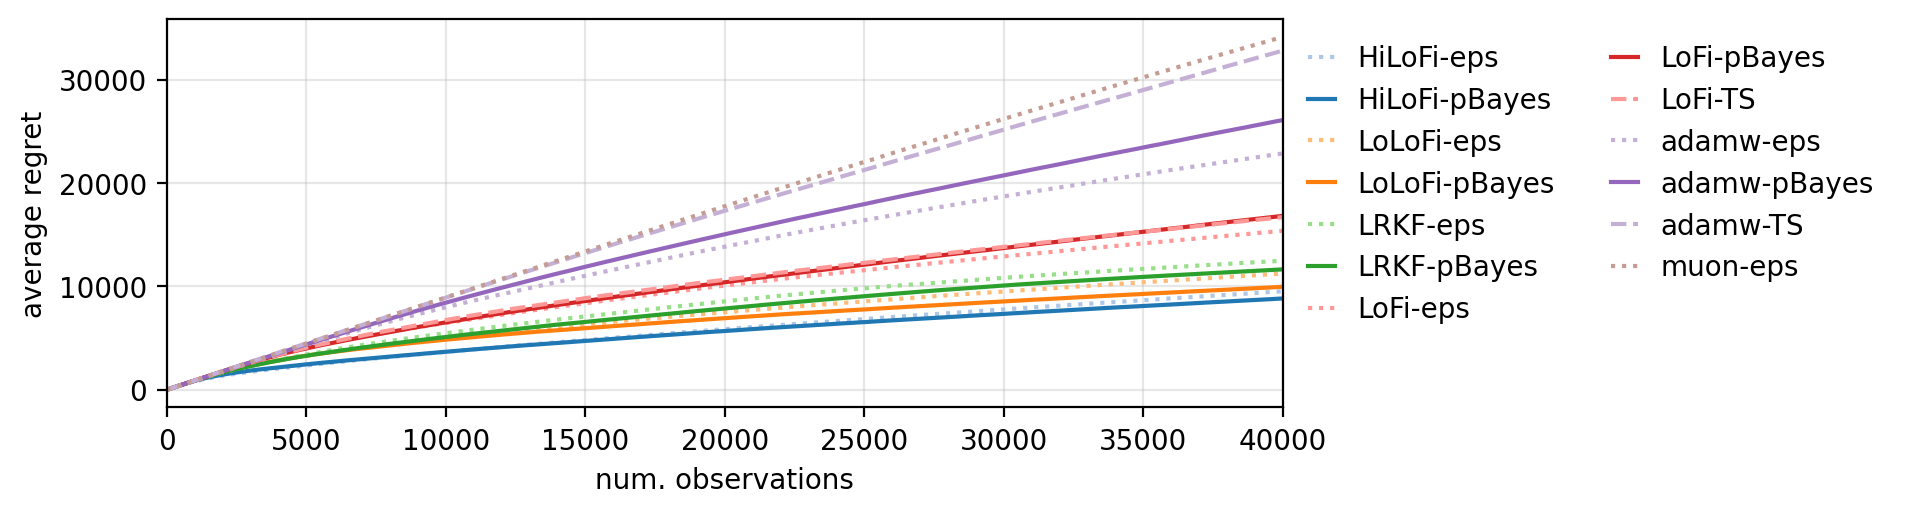

In [538]:
%%time
fig, ax = plt.subplots(figsize=(7.2, 4.2 * 0.6))

res_methods = {}
rewards_all = {}

colors = sns.color_palette("tab20")
hatches = ["x", "o"]
for i, agent in enumerate(sorted(agents)):
    agent_path_predictive = f"./output/{agent}_predictive_bayes_{date}.pkl"
    agent_path_ts = f"./output/{agent}_ts_{date}.pkl"
    agent_path_eps = f"./output/{agent}_eps_5_{date}.pkl"

    agent = agent_map[agent]

    ############ Epsilon greedy ############

    res = pd.read_pickle(agent_path_eps)
    plot_regret(
        res["rewards"].T, label=f"{agent}-eps", linestyle="dotted",
        color=colors[2 * i  + 1], hatch=hatches[(2 * i  + 1) % 2]
    )

    name_agent = f"{agent}-eps"
    rewards_all[name_agent] = res["rewards"].T

    res_methods[name_agent] = {
        "reward": res["rewards"].sum(axis=1).mean(),
        "regret": (40_000 - res["rewards"].sum(axis=1)).mean(),
        "regret_std": (40_000 - res["rewards"].sum(axis=1)).std(),
        "time": res["time"],
        "reward_prop": (res["rewards"].sum(axis=1) / 40_000).mean(),
        "reward_prop_std": (res["rewards"].sum(axis=1) / 40_000).std(),
        "sampling": "eps",
        "agent": agent,
    }



    if agent in ["muon"]:
        continue

    ############ Predictive Bayes ############
    
    res = pd.read_pickle(agent_path_predictive)
    plot_regret(
        res["rewards"].T, label=rf"{agent}-pBayes",
        color=colors[2 * i], hatch=hatches[i % 2]
    )

    name_agent = f"{agent}-pBayes"
    rewards_all[name_agent] = res["rewards"].T

    res_methods[name_agent] = {
        "reward": res["rewards"].sum(axis=1).mean(),
        "regret": (40_000 - res["rewards"].sum(axis=1)).mean(),
        "regret_std": (40_000 - res["rewards"].sum(axis=1)).std(),
        "time": res["time"],
        "reward_prop": (res["rewards"].sum(axis=1) / 40_000).mean(),
        "reward_prop_std": (res["rewards"].sum(axis=1) / 40_000).std(),
        "sampling": "PS",
        "agent": agent,
    }


    
    if agent in ["HiLoFi", "LoLoFi", "LRKF"]:
        continue

    ############ Thompson Sampling ############
    res = pd.read_pickle(agent_path_ts)
    plot_regret(
        res["rewards"].T, label=f"{agent}-TS", linestyle="--",
        color=colors[2 * i  + 1], hatch=hatches[(2 * i  + 1) % 2]
    )

    name_agent = f"{agent}-ts"
    rewards_all[name_agent] = res["rewards"].T
    
    res_methods[name_agent] = {
        "reward": res["rewards"].sum(axis=1).mean(),
        "regret": (40_000 - res["rewards"].sum(axis=1)).mean(),
        "regret_std": (40_000 - res["rewards"].sum(axis=1)).std(),
        "time": res["time"],
        "reward_prop": (res["rewards"].sum(axis=1) / 40_000).mean(),
        "reward_prop_std": (res["rewards"].sum(axis=1) / 40_000).std(),
        "sampling": "TS",
        "agent": agent,
    }



plt.legend(ncol=2, handlelength=1, bbox_to_anchor=(1,1), frameon=False)
plt.xlabel("num. observations")
plt.ylabel("average regret")
plt.grid(alpha=0.3)
plt.xlim(0, 40_000)
# plt.savefig("../figures/mnist-bandit-reward.png", dpi=300, bbox_inches="tight")

res_methods = pd.DataFrame(res_methods)
res_methods.loc["minutes"] = res_methods.loc["time"] / 60
res_methods = res_methods.rename({
    "reward": "cumulative reward",
}).rename({
    "FLoRES-ts": "HiLoFi-pBayes"
}, axis=1)
plt.savefig("../figures/mnist-bandit-regret.png", dpi=300, bbox_inches="tight")

In [539]:
colors = sns.color_palette("colorblind")

In [540]:
agents_target = ["HiLoFi", "LoLoFi", "LRKF", "LoFi", "adamw"]

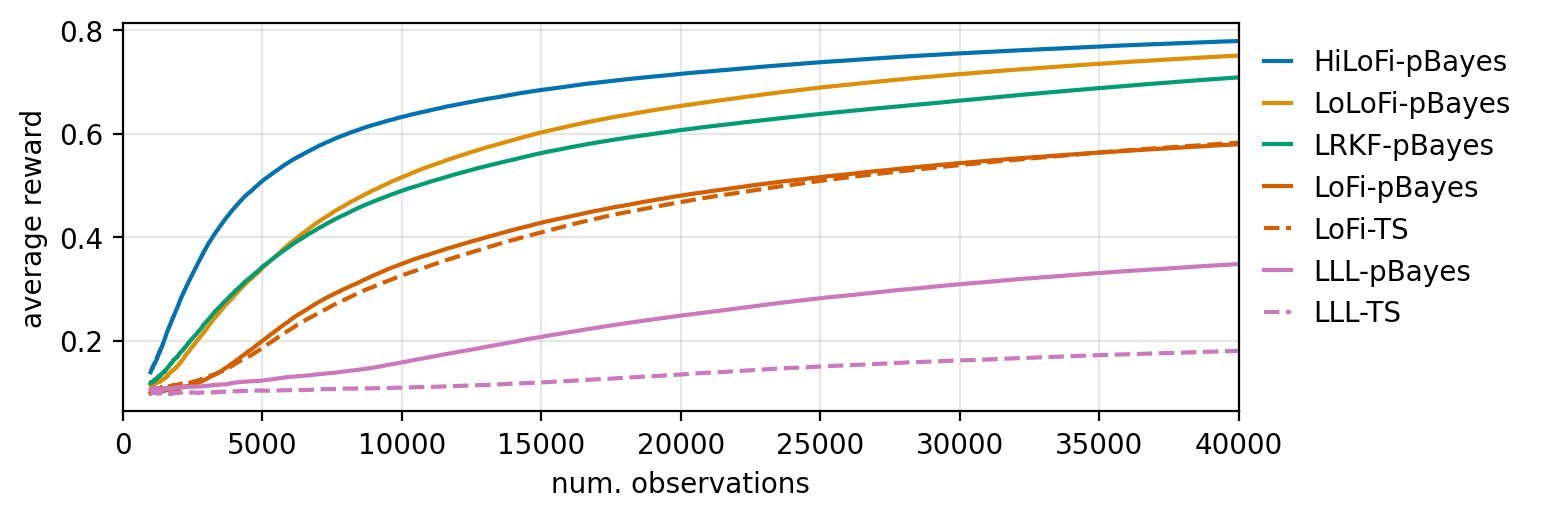

In [541]:
fig, ax = plt.subplots(figsize=(7.2, 4.2 * 0.6))

for color, agent in zip(colors, agents_target):
    name_pbayes = f"{agent}-pBayes"
    name_ts = f"{agent}-ts"

    label = name_pbayes.replace("adamw", "LLL")
    plot_rewards(rewards_all[name_pbayes], hatch="x", color=color, label=label)

    if name_ts in rewards_all:
        label = name_ts.replace("adamw", "LLL").replace("ts", "TS")
        plot_rewards(rewards_all[name_ts], hatch="x", color=color, linestyle="--", label=label)

        
plt.legend(ncol=1, handlelength=1, bbox_to_anchor=(1,1), frameon=False)
plt.xlabel("num. observations")
plt.ylabel("average reward")
plt.grid(alpha=0.3)
plt.xlim(0, 40_000)
plt.savefig("../figures/mnist-bandit-reward.png", dpi=300, bbox_inches="tight")

In [542]:
table = res_methods.loc[["regret", "minutes", "sampling", "agent"]].T
table

,regret,minutes,sampling,agent
HiLoFi-eps,"9,528.20",7.64,eps,HiLoFi
HiLoFi-pBayes,"8,832.30",8.44,PS,HiLoFi
LoLoFi-eps,"11,234.10",2.82,eps,LoLoFi
LoLoFi-pBayes,"9,961.50",3.67,PS,LoLoFi
LRKF-eps,"12,476.70",1.81,eps,LRKF
LRKF-pBayes,"11,645.10",2.51,PS,LRKF
LoFi-eps,"15,371.90",3.68,eps,LoFi
LoFi-pBayes,"16,815.50",4.76,PS,LoFi
LoFi-ts,"16,695.70",38.90,TS,LoFi
adamw-eps,"22,855.10",1.25,eps,adamw


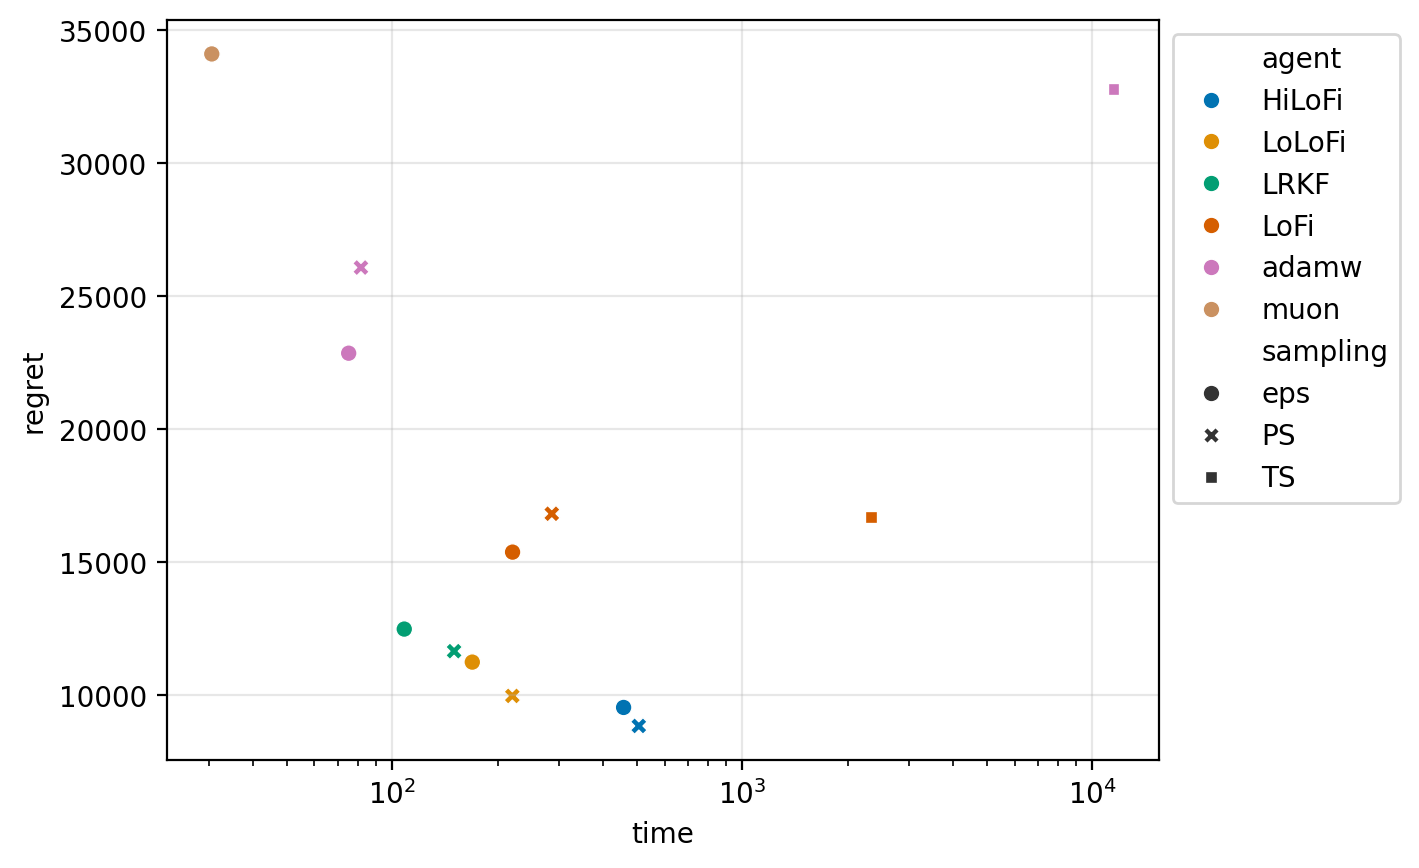

In [543]:
sns.scatterplot(
    y="regret",
    x="time",
    data=res_methods.T.reset_index(),
    hue="agent",
    style="sampling"
)
plt.xscale("log")
plt.legend(bbox_to_anchor=(1,1))
plt.grid(alpha=0.3)

In [544]:
table = (
    res_methods.T.query("sampling != 'eps'")
    .pivot_table(index="agent", columns="sampling", values=["cumulative reward", "minutes"])
)

table

cumulative reward           minutes       
sampling                PS        TS      PS     TS
agent                                              
HiLoFi           31,167.70       NaN    8.44    NaN
LRKF             28,354.90       NaN    2.51    NaN
LoFi             23,184.50 23,304.30    4.76  38.90
LoLoFi           30,038.50       NaN    3.67    NaN
adamw            13,922.30  7,201.90    1.36 191.55

In [545]:
res_methods.T.pivot_table(index="agent", columns="sampling", values=["cumulative reward", "time"])

cumulative reward                       time                 
sampling                PS        TS       eps     PS        TS    eps
agent                                                                 
HiLoFi           31,167.70       NaN 30,471.80 506.44       NaN 458.24
LRKF             28,354.90       NaN 27,523.30 150.32       NaN 108.32
LoFi             23,184.50 23,304.30 24,628.10 285.80  2,334.18 220.81
LoLoFi           30,038.50       NaN 28,765.90 220.48       NaN 169.44
adamw            13,922.30  7,201.90 17,144.90  81.48 11,493.05  75.16
muon                   NaN       NaN  5,886.30    NaN       NaN  30.55

## Time-performance analysis

In [546]:
def replace_name(x):
    x = x.replace("ts", "TS")
    x = x.replace("eps", r"$\epsilon$")
    return x

In [552]:
# res_summary = pd.DataFrame.from_dict(res_methods, orient="index")
res_summary = res_methods.T.copy()
res_summary["prop_reward"] = res_summary["cumulative reward"] / 40_000
names = [replace_name(x) for x in res_summary.index]

# res_summary["agent"] = res_summary["agent"].apply(lambda x: x.replace("adamw", "LLL"))

In [553]:
res_summary

,cumulative reward,regret,regret_std,time,reward_prop,reward_prop_std,sampling,agent,minutes,prop_reward
HiLoFi-eps,"30,471.80","9,528.20",579.11,458.24,0.76,0.01,eps,HiLoFi,7.64,0.76
HiLoFi-pBayes,"31,167.70","8,832.30",502.18,506.44,0.78,0.01,PS,HiLoFi,8.44,0.78
LoLoFi-eps,"28,765.90","11,234.10",943.63,169.44,0.72,0.02,eps,LoLoFi,2.82,0.72
LoLoFi-pBayes,"30,038.50","9,961.50",926.96,220.48,0.75,0.02,PS,LoLoFi,3.67,0.75
LRKF-eps,"27,523.30","12,476.70","4,710.04",108.32,0.69,0.12,eps,LRKF,1.81,0.69
LRKF-pBayes,"28,354.90","11,645.10","6,631.80",150.32,0.71,0.17,PS,LRKF,2.51,0.71
LoFi-eps,"24,628.10","15,371.90","2,556.25",220.81,0.62,0.06,eps,LoFi,3.68,0.62
LoFi-pBayes,"23,184.50","16,815.50","3,043.50",285.80,0.58,0.08,PS,LoFi,4.76,0.58
LoFi-ts,"23,304.30","16,695.70","3,109.49","2,334.18",0.58,0.08,TS,LoFi,38.90,0.58
adamw-eps,"17,144.90","22,855.10",885.60,75.16,0.43,0.02,eps,adamw,1.25,0.43


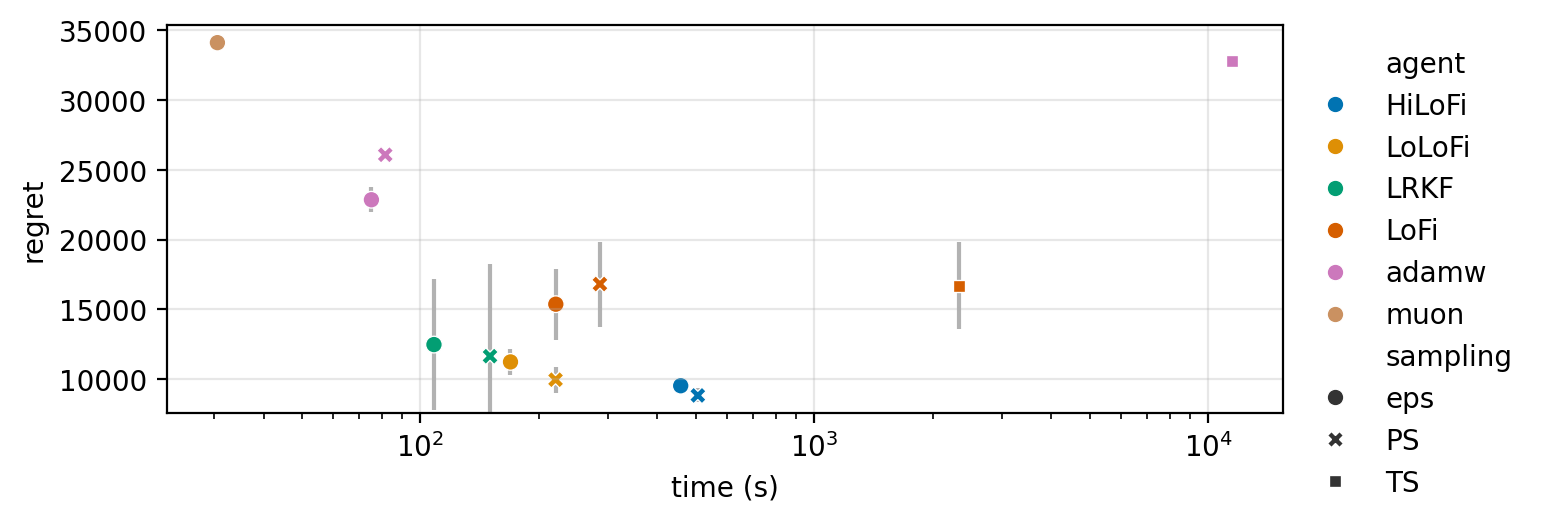

In [554]:
fig, ax = plt.subplots(figsize=(7.2, 4.2 * 0.6))

sns.scatterplot(
    x="time", y="regret", hue="agent",
    data=res_summary.reset_index().assign(index=names),
    style="sampling"
)
ymin, ymax = plt.ylim()

for method, color in zip(res_summary.index, colors):
    part = res_summary.loc[method]
    plt.errorbar(
        x=part["time"], y=part["regret"], yerr=part["regret_std"],
        c="tab:gray", zorder=0, alpha=0.6
    )

plt.ylim(ymin, ymax)

plt.xscale("log")
plt.legend(ncol=1, bbox_to_anchor=(1,1), frameon=False)
plt.xscale("log")
plt.xlabel("time (s)")
plt.ylabel("regret")
plt.grid(alpha=0.3)
plt.savefig("../figures/mnist-bandit-time-regret.png", dpi=300, bbox_inches="tight")